In [3]:
from pathlib import Path
from collections import Counter

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd



In [4]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "peer"

In [5]:
solubility_train = DATA_DIR / "solubility" / "train.csv"
solubility_test = DATA_DIR / "solubility" / "test.csv"
solubility_val = DATA_DIR / "solubility" / "valid.csv"

localization_train = DATA_DIR / "localization" / "train.csv"
localization_test = DATA_DIR / "localization" / "test.csv"
localization_val = DATA_DIR / "localization" / "valid.csv" 

In [6]:
sol = pd.read_csv(solubility_train)
sol_test = pd.read_csv(solubility_test)
sol_valid = pd.read_csv(solubility_val)

loc = pd.read_csv(localization_train)
loc_test = pd.read_csv(localization_test)
loc_valid = pd.read_csv(localization_val)

### Data Overview

In [7]:
sol.head()

,idx,sequence,label,split,dataset
0,0,GMILKTNLFGHTYQFKSITDVLAKANEEKSGDRLAGVAAESAEERV...,1,train,solubility
1,1,MAHHHHHHMSFFRMKRRLNFVVKRGIEELWENSFLDNNVDMKKIEY...,0,train,solubility
2,2,MGSDKIHHHHHHMEKSIQDTIHGVIKLEDWMVEIVDTPQFQRLRRI...,0,train,solubility
3,3,MEKYIHSVEDYHRLISYLENNLNYEDSVVNHVIYVIAKTGMRYGEI...,0,train,solubility
4,4,MSLTDSFTVRSIEGVCFRYPLATPVVTSFGKMLNRPAVFVRVVDED...,0,train,solubility


In [8]:
sol.tail()

,idx,sequence,label,split,dataset
62473,62473,MSSNNRKKLLLMGRSGSGKSSMRSIIFSNYSAFDTRRLGATIDVEH...,1,train,solubility
62474,62474,MGSDKIHHHHHHMAQRVGPTRRGVDGTPVEPLSIKHPNAAGIDIGG...,0,train,solubility
62475,62475,MGSDKIHHHHHHMERNEIEQLVAHGIFPYDQQAKTRLIETAISYIL...,0,train,solubility
62476,62476,MGSDKIHHHHHHMLIISDAHANIHPLKYVIQREKFDKIVFCGDAVD...,0,train,solubility
62477,62477,MKPFQCRICMRNFSRSDHLTTHIRTHTGEKPFACDICGRKFARSDE...,1,train,solubility


In [9]:
loc.head()

,idx,sequence,label,split,dataset
0,0,MEFRGSGATAVEQHLLQSETPGKNGLQATSSDQVGRTLRWFTTVVL...,0,train,localization
1,1,MKNSTAASSRWTKSRLSHFFPSYTNSSGMGAASTDQSSTQGEELHH...,0,train,localization
2,2,MKMASSLAFLLLNFHVSLLLVQLLTPCSAQFSVLGPSGPILAMVGE...,0,train,localization
3,3,MDHSAEKAAANAEVPQELLEEMLWYFRAEDAAPWNYSILVLAVLVV...,0,train,localization
4,4,MIPCRAVLTFARCLIRRKIVTLDSLEDSKLCRCLTTVDLIALGVGS...,0,train,localization


In [10]:
loc.tail()

,idx,sequence,label,split,dataset
8415,8415,QAIGPPYGLCFQCNQKTSSDCTEARRCSPFHEKCYTLYQPDENWMK...,9,train,localization
8416,8416,MPYLLVFLSALCLHGLVYYGSNAQMLSLSPMIGPNVPGLLPGNNIQ...,9,train,localization
8417,8417,MMSKLGVLLTVCPLLFPLTALPPDGDQPADRPAERMQDDISSDEHP...,9,train,localization
8418,8418,MEKSICTSVLVLGLFISSAIGQFCPRDRYEFPPIQCKTHADCGYRS...,9,train,localization
8419,8419,MKLTCVLVVLLLLLPYGDLITNNYIRGAARKVTPWRRNLKTRDVCD...,9,train,localization


In [11]:
print("Solubility Train Shape:", sol.shape)
print("Localization Train Shape:", loc.shape)

Solubility Train Shape: (62478, 5)
Localization Train Shape: (8420, 5)


In [26]:
for df in [sol, sol_valid, sol_test, loc, loc_valid, loc_test]:
    df["length"] = df["sequence"].astype(str).str.len()

In [28]:
sol.columns

Index(['idx', 'sequence', 'label', 'split', 'dataset', 'length'], dtype='str')

## Question 1: What does each dataset contain?

This section summarizes dataset size, number of classes, split structure, and basic sequence length information.

In [29]:
def dataset_summary(name, train, valid, test):
    rows = []

    for split_name, df in [("train", train), ("valid", valid), ("test", test)]:
        rows.append({
            "dataset": name,
            "split": split_name,
            "n_samples": len(df),
            "n_classes": df["label"].nunique(),
            "min_length": df["length"].min(),
            "median_length": df["length"].median(),
            "mean_length": df["length"].mean(),
            "max_length": df["length"].max(),
        })

    return pd.DataFrame(rows)

summary = pd.concat([
    dataset_summary("solubility", sol, sol_valid, sol_test),
    dataset_summary("localization", loc, loc_valid, loc_test)
])

summary

,dataset,split,n_samples,n_classes,min_length,median_length,mean_length,max_length
0,solubility,train,62478,2,19,275.0,298.242437,1200
1,solubility,valid,6942,2,27,275.0,300.779891,1200
2,solubility,test,1999,2,34,260.0,296.329165,1200
0,localization,train,8420,10,40,423.0,470.139430,1000
1,localization,valid,2811,10,40,411.0,466.914265,1000
2,localization,test,2773,10,40,428.0,484.936891,1000


### Interpretation

The solubility dataset is a binary classification task, while localization is a multiclass classification task. This means localization is likely harder and may require macro-F1 rather than accuracy alone.

- Solubility may be better for testing the first end-to-end pipeline.
- Localization may be better for showing whether augmentation affects more biologically specific labels.

## Question 2: Are classes balanced?

"Class balance matters because accuracy can be misleading if one class dominates. If classes are imbalanced, macro-F1 should be emphasized."

In [12]:
sol["label"].value_counts()

label
0    36403
1    26075
Name: count, dtype: int64

In [13]:
loc["label"].value_counts()

label
6    2426
1    1635
9    1185
5     906
0     800
2     516
8     453
3     214
4     192
7      93
Name: count, dtype: int64

In [37]:
def class_distribution_table(name, train, valid, test):
    all_rows = []

    for split_name, df in [("train", train), ("valid", valid), ("test", test)]:
        counts = df["label"].value_counts().sort_index()
        percents = df["label"].value_counts(normalize=True).sort_index() * 100

        for label in counts.index:
            all_rows.append({
                "dataset": name,
                "split": split_name,
                "label": label,
                "count": counts[label],
                "percent": percents[label],
            })

    return pd.DataFrame(all_rows)

class_dist = pd.concat([
    class_distribution_table("solubility", sol, sol_valid, sol_test),
    class_distribution_table("localization", loc, loc_valid, loc_test)
])

class_dist

,dataset,split,label,count,percent
0,solubility,train,0,36403,58.265309
1,solubility,train,1,26075,41.734691
2,solubility,valid,0,4045,58.268511
3,solubility,valid,1,2897,41.731489
4,solubility,test,0,999,49.974987
5,solubility,test,1,1000,50.025013
0,localization,train,0,800,9.501188
1,localization,train,1,1635,19.418052
2,localization,train,2,516,6.128266
3,localization,train,3,214,2.541568


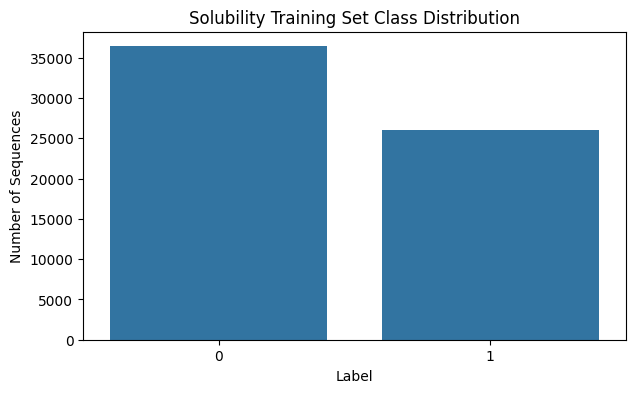

In [38]:
plt.figure(figsize=(7, 4))
sns.countplot(data=sol, x="label")
plt.title("Solubility Training Set Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Sequences")
plt.show()

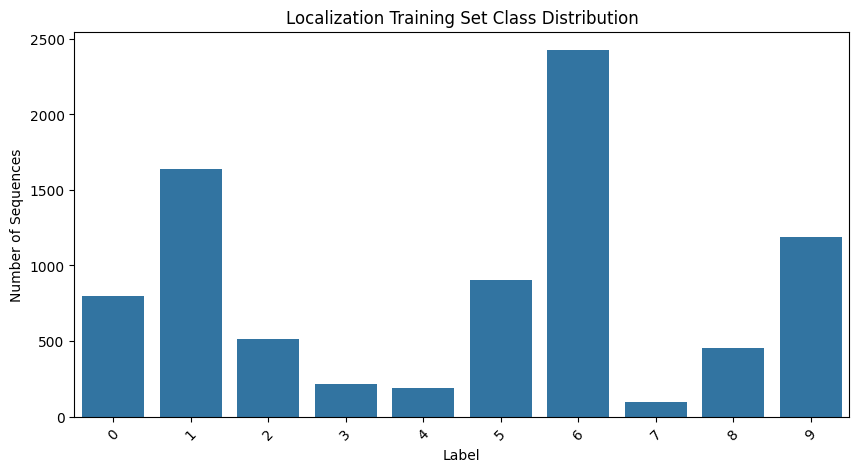

In [39]:
plt.figure(figsize=(10, 5))
sns.countplot(data=loc, x="label", order=sorted(loc["label"].unique()))
plt.title("Localization Training Set Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Sequences")
plt.xticks(rotation=45)
plt.show()

### Interpretation

Questions to answer:

Solubility:
- Lable 0: ~36,000 sequences and Label 1: ~25,000 sequences; overall pretty blanced howwver Lable 0 seems to be more common
- Since the classes are reasonably balanced, performance differences are more likely to reflect the actual effects of mutation and latent-space augmentation.

Localization
- 10 classes that are very uneven 
- Class 6 is dominating; whereas 3,4, and 7 underperform significantly 


Solubility provides a relatively balanced binary classification benchmark that is well-suited for pipeline development and controlled augmentation experiments.

Localization provides a more challenging multiclass benchmark. Minority classes makes localization particularly relevant for investigating whether augmentation methods are most beneficial in low-data settings.


## Question 3: Are train, validation, and test sampled from similar distributions?

downstream performance should reflect generalization, not major distribution differences between splits.

In [40]:
def combine_splits(name, train, valid, test):
    combined = pd.concat([
        train.assign(split_name="train"),
        valid.assign(split_name="valid"),
        test.assign(split_name="test")
    ], ignore_index=True)

    combined["dataset_name"] = name
    return combined

sol_all = combine_splits("solubility", sol, sol_valid, sol_test)
loc_all = combine_splits("localization", loc, loc_valid, loc_test)

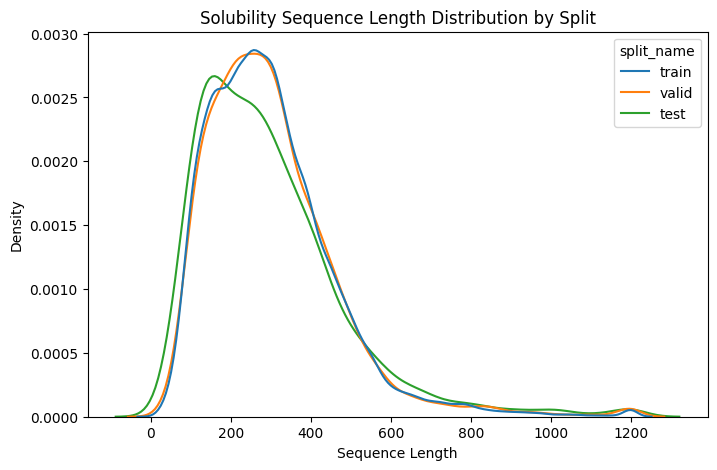

In [41]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=sol_all, x="length", hue="split_name", common_norm=False)
plt.title("Solubility Sequence Length Distribution by Split")
plt.xlabel("Sequence Length")
plt.ylabel("Density")
plt.show()

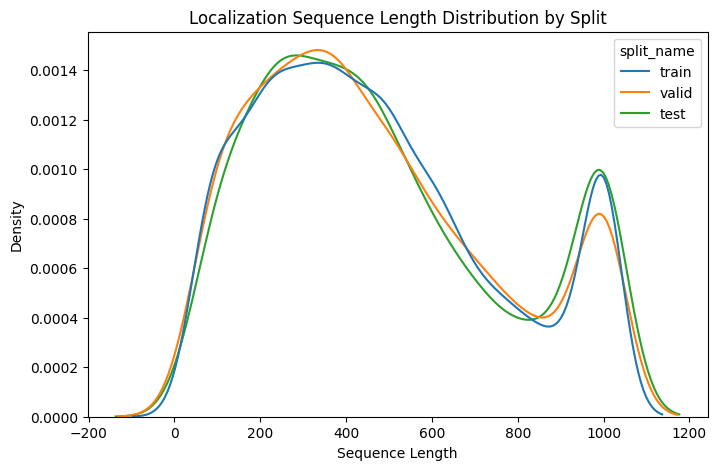

In [42]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=loc_all, x="length", hue="split_name", common_norm=False)
plt.title("Localization Sequence Length Distribution by Split")
plt.xlabel("Sequence Length")
plt.ylabel("Density")
plt.show()

In [47]:
split_label_balance = pd.concat([
    class_distribution_table("solubility", sol, sol_valid, sol_test),
    class_distribution_table("localization", loc, loc_valid, loc_test)
])

split_label_balance

,dataset,split,label,count,percent
0,solubility,train,0,36403,58.265309
1,solubility,train,1,26075,41.734691
2,solubility,valid,0,4045,58.268511
3,solubility,valid,1,2897,41.731489
4,solubility,test,0,999,49.974987
5,solubility,test,1,1000,50.025013
0,localization,train,0,800,9.501188
1,localization,train,1,1635,19.418052
2,localization,train,2,516,6.128266
3,localization,train,3,214,2.541568


### Interpretation

Solubility
- Peak around 200–300 amino acids
- Show a right-skewed distribution
- Have a long tail extending beyond 1000 residues
- The validation curve almost perfectly overlaps the training curve.

Localization
- Bimodal (peak 1 at ~300-400 residues and peak 2 ~950-1000 residues) 

## Question 4: What do protein sequence lengths look like?

Sequence length affects padding, truncation, batching, autoencoder reconstruction difficulty, and ESM embedding cost.

In [17]:
sol["length"].describe() 

count    62478.000000
mean       298.242437
std        158.115356
min         19.000000
25%        185.000000
50%        275.000000
75%        377.000000
max       1200.000000
Name: length, dtype: float64

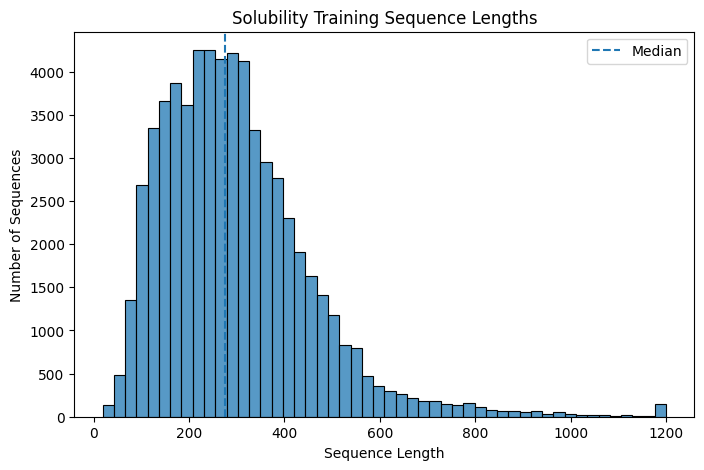

In [48]:
plt.figure(figsize=(8, 5))
sns.histplot(sol["length"], bins=50)
plt.axvline(sol["length"].median(), linestyle="--", label="Median")
plt.title("Solubility Training Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Number of Sequences")
plt.legend()
plt.show()

In [50]:
loc["length"].describe()

count    8420.000000
mean      470.139430
std       277.797598
min        40.000000
25%       249.000000
50%       423.000000
75%       643.000000
max      1000.000000
Name: length, dtype: float64

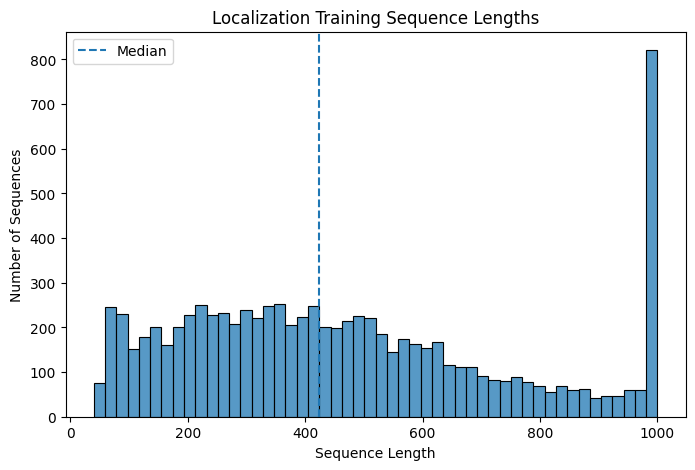

In [49]:
plt.figure(figsize=(8, 5))
sns.histplot(loc["length"], bins=50)
plt.axvline(loc["length"].median(), linestyle="--", label="Median")
plt.title("Localization Training Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Number of Sequences")
plt.legend()
plt.show()

In [51]:
# Percentiles are useful for deciding possible truncation length

percentiles = [50, 75, 90, 95, 99]

pd.DataFrame({
    "percentile": percentiles,
    "solubility_length": np.percentile(sol["length"], percentiles),
    "localization_length": np.percentile(loc["length"], percentiles),
})

,percentile,solubility_length,localization_length
0,50,275.0,423.0
1,75,377.0,643.0
2,90,488.0,975.0
3,95,567.0,1000.0
4,99,844.0,1000.0


### Interpretation


## Question 5: What amino acids dominate each dataset?

This helps us understand the biological composition of each dataset and whether mutation may disrupt rare but meaningful residues.

In [ ]:
def amino_acid_counts(df):
    all_sequences = "".join(df["sequence"].dropna().astype(str))
    counts = Counter(all_sequences)
    total = sum(counts.values())

    rows = []
    for aa, count in sorted(counts.items()):
        rows.append({
            "amino_acid": aa,
            "count": count,
            "frequency": count / total
        })

    return pd.DataFrame(rows)

sol_aa = amino_acid_counts(sol)
loc_aa = amino_acid_counts(loc)

sol_aa.head(20)

,amino_acid,count,frequency
0,A,1492552,0.080100
1,C,238860,0.012819
2,D,1074390,0.057659
3,E,1320130,0.070847
4,F,716460,0.038450
5,G,1268099,0.068054
6,H,608935,0.032679
7,I,1077713,0.057837
8,K,1092351,0.058623
9,L,1749947,0.093914


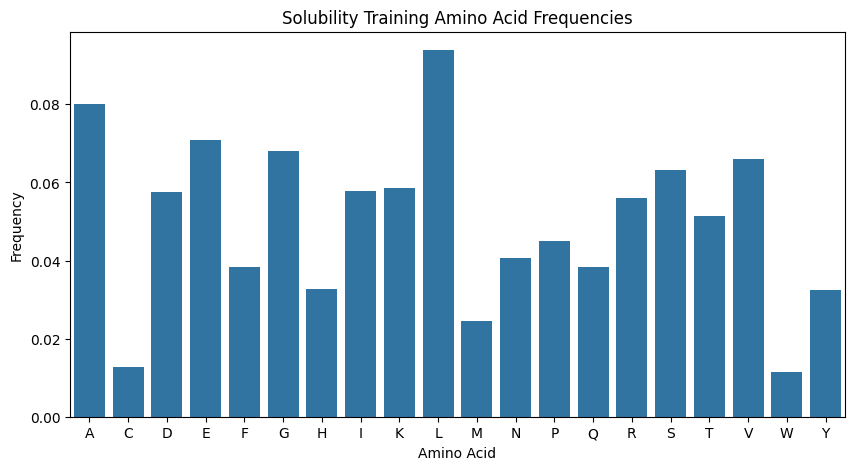

In [55]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sol_aa, x="amino_acid", y="frequency")
plt.title("Solubility Training Amino Acid Frequencies")
plt.xlabel("Amino Acid")
plt.ylabel("Frequency")
plt.show()

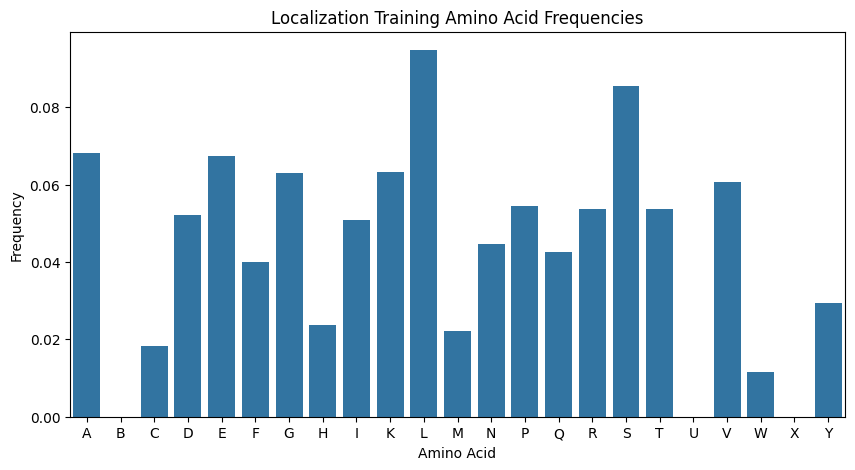

In [56]:
plt.figure(figsize=(10, 5))
sns.barplot(data=loc_aa, x="amino_acid", y="frequency")
plt.title("Localization Training Amino Acid Frequencies")
plt.xlabel("Amino Acid")
plt.ylabel("Frequency")
plt.show()

### Interpretation


## Question 6: Are there duplicate sequences?

Duplicates can inflate performance or reduce the value of augmentation.

In [57]:
def duplicate_summary(name, train, valid, test):
    rows = []

    for split_name, df in [("train", train), ("valid", valid), ("test", test)]:
        rows.append({
            "dataset": name,
            "split": split_name,
            "n_sequences": len(df),
            "exact_duplicate_sequences": df["sequence"].duplicated().sum(),
            "unique_sequences": df["sequence"].nunique()
        })

    return pd.DataFrame(rows)

duplicates = pd.concat([
    duplicate_summary("solubility", sol, sol_valid, sol_test),
    duplicate_summary("localization", loc, loc_valid, loc_test)
])

duplicates

,dataset,split,n_sequences,exact_duplicate_sequences,unique_sequences
0,solubility,train,62478,0,62478
1,solubility,valid,6942,0,6942
2,solubility,test,1999,0,1999
0,localization,train,8420,37,8383
1,localization,valid,2811,4,2807
2,localization,test,2773,5,2768


In [58]:
# Check overlap between train and test sequences

def split_overlap(train, valid, test):
    train_set = set(train["sequence"])
    valid_set = set(valid["sequence"])
    test_set = set(test["sequence"])

    return {
        "train_valid_overlap": len(train_set & valid_set),
        "train_test_overlap": len(train_set & test_set),
        "valid_test_overlap": len(valid_set & test_set),
    }

print("Solubility overlap:", split_overlap(sol, sol_valid, sol_test))
print("Localization overlap:", split_overlap(loc, loc_valid, loc_test))

Solubility overlap: {'train_valid_overlap': 0, 'train_test_overlap': 0, 'valid_test_overlap': 0}
Localization overlap: {'train_valid_overlap': 9, 'train_test_overlap': 0, 'valid_test_overlap': 0}


### Interpretation

Solubility
- There are:

    - no duplicated sequences between train and validation,
    - no duplicated sequences between train and test,
    - no duplicated sequences between validation and test.

## Question 7: How much do direct mutations change protein sequences?

This section simulates random mutation at different rates to understand how aggressive each rate really is.

In [60]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def random_mutate_sequence(sequence, mutation_rate, rng):
    sequence = list(sequence)
    n_mutations = int(round(len(sequence) * mutation_rate))

    if n_mutations == 0:
        return "".join(sequence)

    positions = rng.choice(len(sequence), size=n_mutations, replace=False)

    for pos in positions:
        original = sequence[pos]
        choices = [aa for aa in AMINO_ACIDS if aa != original]
        sequence[pos] = rng.choice(choices)

    return "".join(sequence)

def sequence_identity(seq1, seq2):
    if len(seq1) != len(seq2):
        raise ValueError("Sequences must have equal length for this simple identity calculation.")

    matches = sum(a == b for a, b in zip(seq1, seq2))
    return matches / len(seq1)

def run_mutation_simulation(df, dataset_name, n_samples=100, mutation_rates=[0.05, 0.10, 0.20, 0.30], seed=42):
    rng = np.random.default_rng(seed)
    sample_df = df.sample(n=min(n_samples, len(df)), random_state=seed)

    rows = []

    for _, row in sample_df.iterrows():
        original = row["sequence"]

        for rate in mutation_rates:
            mutated = random_mutate_sequence(original, rate, rng)
            identity = sequence_identity(original, mutated)

            rows.append({
                "dataset": dataset_name,
                "idx": row["idx"],
                "label": row["label"],
                "length": len(original),
                "mutation_rate": rate,
                "n_expected_mutations": int(round(len(original) * rate)),
                "sequence_identity": identity,
                "sequence_drift": 1 - identity,
            })

    return pd.DataFrame(rows)

# Run mutation simulation on solubility and localization datasets
# Code supplied with the help of ChatGPT, see: https://chat.openai.com/

In [68]:
sol_mutation_sim = run_mutation_simulation(sol, "solubility", n_samples=200)
loc_mutation_sim = run_mutation_simulation(loc, "localization", n_samples=200)

mutation_sim = pd.concat([sol_mutation_sim, loc_mutation_sim], ignore_index=True)

mutation_sim.head(25)

,dataset,idx,label,length,mutation_rate,n_expected_mutations,sequence_identity,sequence_drift
0,solubility,26041,0,421,0.05,21,0.950119,0.049881
1,solubility,26041,0,421,0.10,42,0.900238,0.099762
2,solubility,26041,0,421,0.20,84,0.800475,0.199525
3,solubility,26041,0,421,0.30,126,0.700713,0.299287
4,solubility,6558,1,307,0.05,15,0.951140,0.048860
5,solubility,6558,1,307,0.10,31,0.899023,0.100977
6,solubility,6558,1,307,0.20,61,0.801303,0.198697
7,solubility,6558,1,307,0.30,92,0.700326,0.299674
8,solubility,12662,0,514,0.05,26,0.949416,0.050584
9,solubility,12662,0,514,0.10,51,0.900778,0.099222


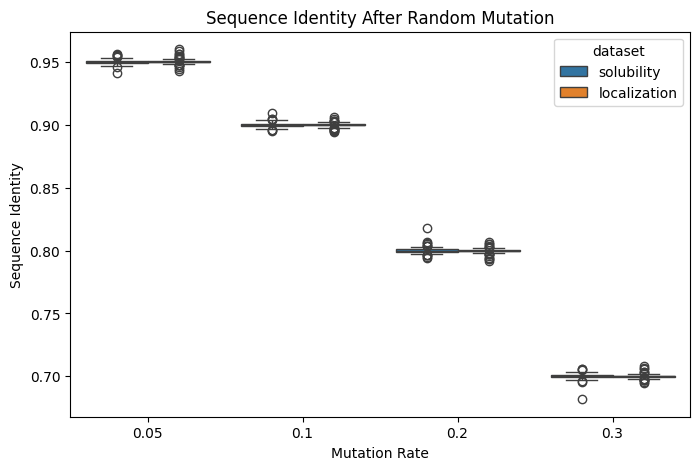

In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=mutation_sim, x="mutation_rate", y="sequence_identity", hue="dataset")
plt.title("Sequence Identity After Random Mutation")
plt.xlabel("Mutation Rate")
plt.ylabel("Sequence Identity")
plt.show()

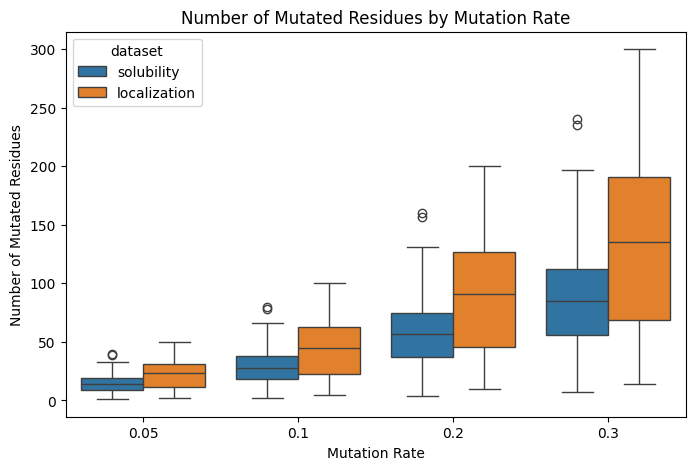

In [63]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=mutation_sim, x="mutation_rate", y="n_expected_mutations", hue="dataset")
plt.title("Number of Mutated Residues by Mutation Rate")
plt.xlabel("Mutation Rate")
plt.ylabel("Number of Mutated Residues")
plt.show()

### Interpretation

Answer:

## Question 8: Which dataset should be the first benchmark?

This section compares solubility and localization to decide which dataset should be used first.

In [69]:
comparison = pd.DataFrame([
    {
        "dataset": "solubility",
        "task_type": "binary" if sol["label"].nunique() == 2 else "multiclass",
        "train_samples": len(sol),
        "valid_samples": len(sol_valid),
        "test_samples": len(sol_test),
        "n_classes": sol["label"].nunique(),
        "median_length": sol["length"].median(),
        "max_length": sol["length"].max(),
        "duplicate_train_sequences": sol["sequence"].duplicated().sum(),
    },
    {
        "dataset": "localization",
        "task_type": "binary" if loc["label"].nunique() == 2 else "multiclass",
        "train_samples": len(loc),
        "valid_samples": len(loc_valid),
        "test_samples": len(loc_test),
        "n_classes": loc["label"].nunique(),
        "median_length": loc["length"].median(),
        "max_length": loc["length"].max(),
        "duplicate_train_sequences": loc["sequence"].duplicated().sum(),
    }
])

comparison

,dataset,task_type,train_samples,valid_samples,test_samples,n_classes,median_length,max_length,duplicate_train_sequences
0,solubility,binary,62478,6942,1999,2,275.0,1200,0
1,localization,multiclass,8420,2811,2773,10,423.0,1000,37
